In [7]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


filename = "result.dat"

# Read file
with open(filename, "r") as f:
    lines = f.readlines()

# Extract I and J from ZONE line
zone_line = [line for line in lines if "ZONE" in line][0]
I = int(re.search(r"I=\s*(\d+)", zone_line).group(1))
J = int(re.search(r"J=\s*(\d+)", zone_line).group(1))

print(f"Grid size: I={I}, J={J}")

# Find where numeric data starts
data_start = 0
for i, line in enumerate(lines):
    if re.match(r"\s*[-+0-9.]", line):
        data_start = i
        break

# Load numerical data
df = pd.read_csv(
    filename,
    sep=r"\s+",
    skiprows=data_start,
    names=["X", "Y", "U", "V", "P"],
    engine="python"
)

# Reshape into grid
X = df["X"].values.reshape(J, I)
Y = df["Y"].values.reshape(J, I)
U = df["U"].values.reshape(J, I)
V = df["V"].values.reshape(J, I)

velocity_mag = np.sqrt(U**2 + V**2)


Grid size: I=40, J=40


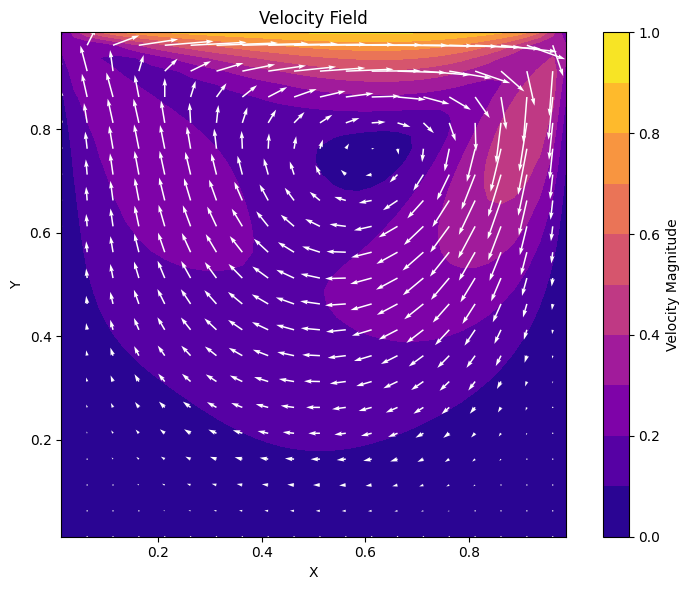

In [8]:
# --------- PLOTTING ---------
plt.figure(figsize=(8,6))

# Contour plot of velocity magnitude
contour = plt.contourf(X, Y, velocity_mag, levels=10, cmap="plasma")
plt.colorbar(contour, label="Velocity Magnitude")

# Quiver plot (velocity vectors)
step=2
plt.quiver(
    X[::step, ::step],
    Y[::step, ::step],
    U[::step, ::step],
    V[::step, ::step],
    color="white",
    scale=5
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Velocity Field")
plt.gca().set_aspect('equal')

plt.tight_layout()
plt.show()


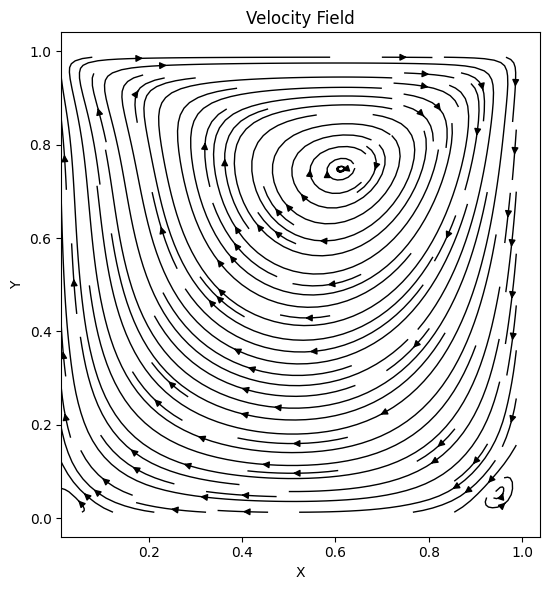

In [13]:
# --------- PLOTTING ---------
plt.figure(figsize=(8,6))

# Contour plot of velocity magnitude

# Streamlines
plt.streamplot(
    X, Y, U, V,
    color="black",      # streamline color
    density=1.5,        # controls number of lines
    linewidth=1
)


plt.xlabel("X")
plt.ylabel("Y")
plt.title("Velocity Field")
plt.gca().set_aspect('equal')

plt.tight_layout()
plt.show()